In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
# %%time
# dataset = 'osm_railway'
# collection_id = 'vector-osm-railway'

# # Stac collection title
# collection_title = 'OSM Railway'

# # Stac collection description
# description = '''Open Street Map (OSM) Railway Network (non-nan "railway" key).'''

# # Parquet file custom metadata
# custom_meta_content = {'About': description}

# dt_col = 'osm_timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'osm_id'
# dimension_values = {}

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 26
# target_level = 14
# max_depth = 14
# max_inflation = 100 #None
# target_rows = 1e6

# grid = nestedgrid.World(4326)
# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore.Vectorstore(
#     dataset=dataset,
#     collection_id=collection_id,
#     dimension_values=dimension_values,
#     grid=grid,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     max_level=max_level,
#     target_level=target_level,
#     max_depth=max_depth,
#     max_inflation=max_inflation,
#     target_rows=target_rows,
#     custom_meta_content=custom_meta_content,
#     verbose=True,
# )

# vs.write_metadata()
# vs.read_metadata()

# geoparquet_path = '/data/vector/osm/collections/railway'
# files = glob(os.path.join(geoparquet_path, '*.parquet'))

# # Find the set of all columns
# cols = set([])
# for file in files:
#     ddf = dask_geopandas.read_parquet(file)
#     cols = cols | set(ddf.columns)

# # A few files strangely still have the'all_tags" column
# cols = cols - set(['all_tags'])
# cols = sorted(cols)

# def utcfromtimestamp(x):
#     try:
#         return datetime.utcfromtimestamp(x).replace(tzinfo=pytz.utc)
#     except OSError as e:
#         # Maybe value was too large (nano second timestamp definition)
#         return datetime.utcfromtimestamp(x/1e9).replace(tzinfo=pytz.utc)
            
# def load_clean_partial(file):
#     """Harmonize partial files before uploading."""
#     gdf_part = geopandas.read_parquet(file)

#     # set UTC timestamp
#     # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
#     gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

#     # Fill in missing columns
#     missing_cols = list(set(cols) - set(gdf_part.columns))
#     for col in missing_cols:
#         gdf_part[col] = None

#     gdf_part['geometry'] = gdf_part['geometry'].make_valid()

#     # Debug: In some cases z-order has both int, nan, and string values, so unify float
#     if 'z_order' in gdf_part:
#         gdf_part['z_order'] = gdf_part['z_order'].astype(float)

#     # Order the columns uniformly
#     return gdf_part[cols]

# # for file in files:
# #     chunk = load_clean_partial(file)

In [3]:
# %%time
# dataset = 'osm_power'
# collection_id = 'vector-osm-power'

# # Stac collection title
# collection_title = 'OSM Power'

# # Stac collection description
# description = '''Open Street Map (OSM) Power Network (non-nan "power" key).'''

# # Parquet file custom metadata
# custom_meta_content = {'About': description}

# dt_col = 'osm_timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'osm_id'
# dimension_values = {}

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 26
# target_level = 14
# max_depth = 14
# max_inflation = 100 #None
# target_rows = 1e6

# grid = nestedgrid.World(4326)
# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore.Vectorstore(
#     dataset=dataset,
#     collection_id=collection_id,
#     dimension_values=dimension_values,
#     grid=grid,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     max_level=max_level,
#     target_level=target_level,
#     max_depth=max_depth,
#     max_inflation=max_inflation,
#     target_rows=target_rows,
#     custom_meta_content=custom_meta_content,
#     verbose=True,
# )

# vs.write_metadata()
# vs.read_metadata()

# geoparquet_path = '/data/vector/osm/collections/power'
# files = glob(os.path.join(geoparquet_path, '*.parquet'))

# # Find the set of all columns
# cols = set([])
# for file in files:
#     ddf = dask_geopandas.read_parquet(file, split_row_groups=False)
#     cols = cols | set(ddf.columns)

# # A few files strangely still have the'all_tags" column
# cols = cols - set(['all_tags'])
# cols = sorted(cols)

# def utcfromtimestamp(x):
#     try:
#         return datetime.utcfromtimestamp(x).replace(tzinfo=pytz.utc)
#     except OSError as e:
#         # Maybe value was too large (nano second timestamp definition)
#         return datetime.utcfromtimestamp(x/1e9).replace(tzinfo=pytz.utc)
            
# def load_clean_partial(file):
#     """Harmonize partial files before uploading."""
#     gdf_part = geopandas.read_parquet(file)

#     # set UTC timestamp
#     # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
#     gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

#     # Fill in missing columns
#     missing_cols = list(set(cols) - set(gdf_part.columns))
#     for col in missing_cols:
#         gdf_part[col] = None

#     gdf_part['geometry'] = gdf_part['geometry'].make_valid()

#     # Debug: In some cases z-order has both int, nan, and string values, so unify float
#     if 'z_order' in gdf_part:
#         gdf_part['z_order'] = gdf_part['z_order'].astype(float)

#     # Order the columns uniformly
#     return gdf_part[cols]

# # for file in files:
# #     chunk = load_clean_partial(file)

In [4]:
# %%time
# dataset = 'osm_poi'
# collection_id = 'vector-osm-poi'

# # Stac collection title
# collection_title = 'OSM Points Of Interest'

# # Stac collection description
# description = '''Open Street Map (OSM) Points of Interest (non-nan "amenity", "shop", "tourism", "craft", "emergency", "historic", "office", "sport", "leisure", "place", "aeroway" keys).'''

# # Parquet file custom metadata
# custom_meta_content = {'About': description}

# dt_col = 'osm_timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'osm_id'
# dimension_values = {}

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 26
# target_level = 14
# max_depth = 14
# max_inflation = 100 #None
# target_rows = 1e6

# grid = nestedgrid.World(4326)
# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore.Vectorstore(
#     dataset=dataset,
#     collection_id=collection_id,
#     dimension_values=dimension_values,
#     grid=grid,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     max_level=max_level,
#     target_level=target_level,
#     max_depth=max_depth,
#     max_inflation=max_inflation,
#     target_rows=target_rows,
#     custom_meta_content=custom_meta_content,
#     verbose=True,
# )

# vs.write_metadata()
# vs.read_metadata()

# geoparquet_path = '/data/vector/osm/collections/poi'
# files = glob(os.path.join(geoparquet_path, '*.parquet'))

# # Find the set of all columns
# cols = set([])
# for file in files:
#     ddf = dask_geopandas.read_parquet(file, split_row_groups=False)
#     cols = cols | set(ddf.columns)

# # A few files strangely still have the'all_tags" column
# cols = cols - set(['all_tags'])
# cols = sorted(cols)

# def utcfromtimestamp(x):
#     try:
#         return datetime.utcfromtimestamp(x).replace(tzinfo=pytz.utc)
#     except OSError as e:
#         # Maybe value was too large (nano second timestamp definition)
#         return datetime.utcfromtimestamp(x/1e9).replace(tzinfo=pytz.utc)
            
# def load_clean_partial(file):
#     """Harmonize partial files before uploading."""
#     gdf_part = geopandas.read_parquet(file)

#     # set UTC timestamp
#     # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
#     gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

#     # Fill in missing columns
#     missing_cols = list(set(cols) - set(gdf_part.columns))
#     for col in missing_cols:
#         gdf_part[col] = None

#     gdf_part['geometry'] = gdf_part['geometry'].make_valid()

#     # Debug: In some cases z-order has both int, nan, and string values, so unify float
#     if 'z_order' in gdf_part:
#         gdf_part['z_order'] = gdf_part['z_order'].astype(float)

#     # Order the columns uniformly
#     return gdf_part[cols]

# # for file in files:
# #     chunk = load_clean_partial(file)

In [5]:
# %%time
# dataset = 'osm_building'
# collection_id = 'vector-osm-building'

# # Stac collection title
# collection_title = 'OSM Building'

# # Stac collection description
# description = '''Open Street Map (OSM) Buildings (non-nan "building" key).'''

# # Parquet file custom metadata
# custom_meta_content = {'About': description}

# dt_col = 'osm_timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'osm_id'
# dimension_values = {}

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 26
# target_level = 14
# max_depth = 14
# max_inflation = 100 #None
# target_rows = 1e6

# grid = nestedgrid.World(4326)
# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore.Vectorstore(
#     dataset=dataset,
#     collection_id=collection_id,
#     dimension_values=dimension_values,
#     grid=grid,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     max_level=max_level,
#     target_level=target_level,
#     max_depth=max_depth,
#     max_inflation=max_inflation,
#     target_rows=target_rows,
#     custom_meta_content=custom_meta_content,
#     verbose=True,
# )

# vs.write_metadata()
# vs.read_metadata()

# geoparquet_path = '/data/vector/osm/collections/building'
# files = glob(os.path.join(geoparquet_path, '*.parquet'))

# # Find the set of all columns
# cols = set([])
# for file in files:
#     ddf = dask_geopandas.read_parquet(file, split_row_groups=False)
#     cols = cols | set(ddf.columns)

# # A few files strangely still have the'all_tags" column
# cols = cols - set(['all_tags'])
# cols = sorted(cols)

# def utcfromtimestamp(x):
#     try:
#         return datetime.utcfromtimestamp(x).replace(tzinfo=pytz.utc)
#     except OSError as e:
#         # Maybe value was too large (nano second timestamp definition)
#         return datetime.utcfromtimestamp(x/1e9).replace(tzinfo=pytz.utc)
            
# def load_clean_partial(file):
#     """Harmonize partial files before uploading."""
#     gdf_part = geopandas.read_parquet(file)

#     # set UTC timestamp
#     # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
#     gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

#     # Fill in missing columns
#     missing_cols = list(set(cols) - set(gdf_part.columns))
#     for col in missing_cols:
#         gdf_part[col] = None

#     gdf_part['geometry'] = gdf_part['geometry'].make_valid()

#     # Debug: In some cases z-order has both int, nan, and string values, so unify float
#     if 'z_order' in gdf_part:
#         gdf_part['z_order'] = gdf_part['z_order'].astype(float)

#     # Order the columns uniformly
#     return gdf_part[cols]

# # for file in files:
# #     chunk = load_clean_partial(file)

In [6]:
# %%time
# dataset = 'osm_waterway'
# collection_id = 'vector-osm-waterway'

# # Stac collection title
# collection_title = 'OSM Waterway'

# # Stac collection description
# description = '''Open Street Map (OSM) Waterways (non-nan "waterway" key).'''

# # Parquet file custom metadata
# custom_meta_content = {'About': description}

# dt_col = 'osm_timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'osm_id'
# dimension_values = {}

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 26
# target_level = 14
# max_depth = 14
# max_inflation = 100 #None
# target_rows = 1e6

# grid = nestedgrid.World(4326)
# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore.Vectorstore(
#     dataset=dataset,
#     collection_id=collection_id,
#     dimension_values=dimension_values,
#     grid=grid,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     max_level=max_level,
#     target_level=target_level,
#     max_depth=max_depth,
#     max_inflation=max_inflation,
#     target_rows=target_rows,
#     custom_meta_content=custom_meta_content,
#     verbose=True,
# )

# vs.write_metadata()
# vs.read_metadata()

# geoparquet_path = '/data/vector/osm/collections/waterway'
# files = glob(os.path.join(geoparquet_path, '*.parquet'))

# # Find the set of all columns
# cols = set([])
# for file in files:
#     ddf = dask_geopandas.read_parquet(file, split_row_groups=False)
#     cols = cols | set(ddf.columns)

# # A few files strangely still have the'all_tags" column
# cols = cols - set(['all_tags'])
# cols = sorted(cols)

# def utcfromtimestamp(x):
#     try:
#         return datetime.utcfromtimestamp(x).replace(tzinfo=pytz.utc)
#     except OSError as e:
#         # Maybe value was too large (nano second timestamp definition)
#         return datetime.utcfromtimestamp(x/1e9).replace(tzinfo=pytz.utc)
            
# def load_clean_partial(file):
#     """Harmonize partial files before uploading."""
#     gdf_part = geopandas.read_parquet(file)

#     # set UTC timestamp
#     # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
#     gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

#     # Fill in missing columns
#     missing_cols = list(set(cols) - set(gdf_part.columns))
#     for col in missing_cols:
#         gdf_part[col] = None

#     gdf_part['geometry'] = gdf_part['geometry'].make_valid()

#     # Debug: In some cases z-order has both int, nan, and string values, so unify float
#     if 'z_order' in gdf_part:
#         gdf_part['z_order'] = gdf_part['z_order'].astype(float)

#     # Order the columns uniformly
#     return gdf_part[cols]

# # for file in files:
# #     chunk = load_clean_partial(file)

In [7]:
# %%time
# dataset = 'osm_boundary'
# collection_id = 'vector-osm-boundary'

# # Stac collection title
# collection_title = 'OSM Boundary'

# # Stac collection description
# description = '''Open Street Map (OSM) Bounderies (non-nan "boundary" key).'''

# # Parquet file custom metadata
# custom_meta_content = {'About': description}

# dt_col = 'osm_timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'osm_id'
# dimension_values = {}

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 26
# target_level = 14
# max_depth = 14
# max_inflation = 100 #None
# target_rows = 1e5 #1e6

# grid = nestedgrid.World(4326)
# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore.Vectorstore(
#     dataset=dataset,
#     collection_id=collection_id,
#     dimension_values=dimension_values,
#     grid=grid,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     max_level=max_level,
#     target_level=target_level,
#     max_depth=max_depth,
#     max_inflation=max_inflation,
#     target_rows=target_rows,
#     custom_meta_content=custom_meta_content,
#     verbose=True,
# )

# vs.write_metadata()
# vs.read_metadata()

# geoparquet_path = '/data/vector/osm/collections/boundary'
# files = glob(os.path.join(geoparquet_path, '*.parquet'))

# # Find the set of all columns
# cols = set([])
# for file in files:
#     ddf = dask_geopandas.read_parquet(file, split_row_groups=False)
#     cols = cols | set(ddf.columns)

# # A few files strangely still have the'all_tags" column
# cols = cols - set(['all_tags'])
# cols = sorted(cols)

# def utcfromtimestamp(x):
#     try:
#         return datetime.utcfromtimestamp(x).replace(tzinfo=pytz.utc)
#     except OSError as e:
#         # Maybe value was too large (nano second timestamp definition)
#         return datetime.utcfromtimestamp(x/1e9).replace(tzinfo=pytz.utc)
            
# def load_clean_partial(file):
#     """Harmonize partial files before uploading."""
#     gdf_part = geopandas.read_parquet(file)

#     # set UTC timestamp
#     # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
#     gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

#     # Fill in missing columns
#     missing_cols = list(set(cols) - set(gdf_part.columns))
#     for col in missing_cols:
#         gdf_part[col] = None

#     gdf_part['geometry'] = gdf_part['geometry'].make_valid()

#     # Debug: In some cases z-order has both int, nan, and string values, so unify float
#     if 'z_order' in gdf_part:
#         gdf_part['z_order'] = gdf_part['z_order'].astype(float)

#     # Order the columns uniformly
#     return gdf_part[cols]

# # for file in files:
# #     chunk = load_clean_partial(file)

In [8]:
# %%time
# dataset = 'osm_natural'
# collection_id = 'vector-osm-natural'

# # Stac collection title
# collection_title = 'OSM Natural'

# # Stac collection description
# description = '''Open Street Map (OSM) Natural (non-nan "natural" or "geological" keys).'''

# # Parquet file custom metadata
# custom_meta_content = {'About': description}

# dt_col = 'osm_timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'osm_id'
# dimension_values = {}

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 26
# target_level = 14
# max_depth = 14
# max_inflation = 100 #None
# target_rows = 1e6

# grid = nestedgrid.World(4326)
# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore.Vectorstore(
#     dataset=dataset,
#     collection_id=collection_id,
#     dimension_values=dimension_values,
#     grid=grid,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     max_level=max_level,
#     target_level=target_level,
#     max_depth=max_depth,
#     max_inflation=max_inflation,
#     target_rows=target_rows,
#     custom_meta_content=custom_meta_content,
#     verbose=True,
# )

# vs.write_metadata()
# vs.read_metadata()

# geoparquet_path = '/data/vector/osm/collections/natural'
# files = glob(os.path.join(geoparquet_path, '*.parquet'))

# # Find the set of all columns
# cols = set([])
# for file in files:
#     ddf = dask_geopandas.read_parquet(file, split_row_groups=False)
#     cols = cols | set(ddf.columns)

# # A few files strangely still have the'all_tags" column
# cols = cols - set(['all_tags'])
# cols = sorted(cols)

# def utcfromtimestamp(x):
#     try:
#         return datetime.utcfromtimestamp(x).replace(tzinfo=pytz.utc)
#     except OSError as e:
#         # Maybe value was too large (nano second timestamp definition)
#         return datetime.utcfromtimestamp(x/1e9).replace(tzinfo=pytz.utc)
            
# def load_clean_partial(file):
#     """Harmonize partial files before uploading."""
#     gdf_part = geopandas.read_parquet(file)

#     # set UTC timestamp
#     # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
#     gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

#     # Fill in missing columns
#     missing_cols = list(set(cols) - set(gdf_part.columns))
#     for col in missing_cols:
#         gdf_part[col] = None

#     gdf_part['geometry'] = gdf_part['geometry'].make_valid()

#     # Debug: In some cases z-order has both int, nan, and string values, so unify float
#     if 'z_order' in gdf_part:
#         gdf_part['z_order'] = gdf_part['z_order'].astype(float)

#     # Order the columns uniformly
#     return gdf_part[cols]

# # for file in files:
# #     chunk = load_clean_partial(file)

In [9]:
# %%time
# dataset = 'osm_landuse'
# collection_id = 'vector-osm-landuse'

# # Stac collection title
# collection_title = 'OSM Landuse'

# # Stac collection description
# description = '''Open Street Map (OSM) Landuse (non-nan "landuse" key).'''

# # Parquet file custom metadata
# custom_meta_content = {'About': description}

# dt_col = 'osm_timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'osm_id'
# dimension_values = {}

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 26
# target_level = 14
# max_depth = 14
# max_inflation = 100 #None
# target_rows = 1e6

# grid = nestedgrid.World(4326)
# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore.Vectorstore(
#     dataset=dataset,
#     collection_id=collection_id,
#     dimension_values=dimension_values,
#     grid=grid,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     max_level=max_level,
#     target_level=target_level,
#     max_depth=max_depth,
#     max_inflation=max_inflation,
#     target_rows=target_rows,
#     custom_meta_content=custom_meta_content,
#     verbose=True,
# )

# vs.write_metadata()
# vs.read_metadata()

# geoparquet_path = '/data/vector/osm/collections/landuse'
# files = glob(os.path.join(geoparquet_path, '*.parquet'))

# # Find the set of all columns
# cols = set([])
# for file in files:
#     ddf = dask_geopandas.read_parquet(file, split_row_groups=False)
#     cols = cols | set(ddf.columns)

# # A few files strangely still have the'all_tags" column
# cols = cols - set(['all_tags'])
# cols = sorted(cols)

# def utcfromtimestamp(x):
#     try:
#         return datetime.utcfromtimestamp(x).replace(tzinfo=pytz.utc)
#     except OSError as e:
#         # Maybe value was too large (nano second timestamp definition)
#         return datetime.utcfromtimestamp(x/1e9).replace(tzinfo=pytz.utc)
            
# def load_clean_partial(file):
#     """Harmonize partial files before uploading."""
#     gdf_part = geopandas.read_parquet(file)

#     # set UTC timestamp
#     # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
#     gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

#     # Fill in missing columns
#     missing_cols = list(set(cols) - set(gdf_part.columns))
#     for col in missing_cols:
#         gdf_part[col] = None

#     gdf_part['geometry'] = gdf_part['geometry'].make_valid()

#     # Debug: In some cases z-order has both int, nan, and string values, so unify float
#     if 'z_order' in gdf_part:
#         gdf_part['z_order'] = gdf_part['z_order'].astype(float)

#     # Order the columns uniformly
#     return gdf_part[cols]

# # for file in files:
# #     chunk = load_clean_partial(file)

In [10]:
%%time
dataset = 'osm_road'
collection_id = 'vector-osm-road'

# Stac collection title
collection_title = 'OSM Road'

# Stac collection description
description = '''Open Street Map (OSM) Road network (non-nan "highway" key).'''

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'osm_timestamp'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'osm_id'
dimension_values = {}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 1e6

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

geoparquet_path = '/data/vector/osm/collections/road'
files = glob(os.path.join(geoparquet_path, '*.parquet'))

# Find the set of all columns
cols = set([])
for file in files:
    ddf = dask_geopandas.read_parquet(file, split_row_groups=False)
    cols = cols | set(ddf.columns)

# A few files strangely still have the'all_tags" column
cols = cols - set(['all_tags'])
cols = sorted(cols)

def utcfromtimestamp(x):
    try:
        return datetime.utcfromtimestamp(x).replace(tzinfo=pytz.utc)
    except OSError as e:
        # Maybe value was too large (nano second timestamp definition)
        return datetime.utcfromtimestamp(x/1e9).replace(tzinfo=pytz.utc)
            
def load_clean_partial(file):
    """Harmonize partial files before uploading."""
    gdf_part = geopandas.read_parquet(file)

    # set UTC timestamp
    # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
    gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

    # Fill in missing columns
    missing_cols = list(set(cols) - set(gdf_part.columns))
    for col in missing_cols:
        gdf_part[col] = None

    gdf_part['geometry'] = gdf_part['geometry'].make_valid()

    # Debug: In some cases z-order has both int, nan, and string values, so unify float
    if 'z_order' in gdf_part:
        gdf_part['z_order'] = gdf_part['z_order'].astype(float)

    # Order the columns uniformly
    return gdf_part[cols]

# for file in files:
#     chunk = load_clean_partial(file)

CPU times: total: 2.22 s
Wall time: 22.4 s


In [11]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x1f241e1ef50>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'osm_road',
 'collection_id': 'vector-osm-road',
 'temporal_levels': [],
 'dimension_values': {},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/osm_road',
 'grid_directory': 'data/vectorstore/osm_road/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/osm_road/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/osm_road/grid=World(4326)/index',
 'dt_col': 'osm_timestamp',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'osm_id',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['osm_timestamp', 'osm_id'],
 'max_level': 26,
 'target_level': 14,
 'max_depth': 14,
 'max_inflation': 100,
 'target_rows': 1000000.0,
 'row_group_size': 100000.0,
 'custom_meta_conte

# Chunked successive ingestion

In [12]:
# %%time
# n_chunks = 1
# for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
#     print('Chunk', i)
#     vs.partial_upload(
#         chunk,
#         defrag=False,
#         index=False,
#         geometry_area=False,
#         geometry_length=False,
#     )

In [13]:
%%time
for file in files:
    chunk = load_clean_partial(file)
    print(file)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

/data/vector/osm/collections/road\0q00.parquet
df_root 57155
Time for indexing the root of each unique geometry in seconds 0.518
cannot call `vectorize` on size 0 inputs unless `otypes` is set
Failed to use numpy. Switching to pandas
distributed over 1 partitions
Time for creating partitions in seconds 0.407
Time for writing GeoDataFrame to GeoParquet partitions 1.013
/data/vector/osm/collections/road\0q010.parquet
df_root 98679
Time for indexing the root of each unique geometry in seconds 0.874
distributed over 1 partitions
Time for creating partitions in seconds 0.763
Time for writing GeoDataFrame to GeoParquet partitions 1.713
/data/vector/osm/collections/road\0q011.parquet
df_root 63
Time for indexing the root of each unique geometry in seconds 0.059
cannot call `vectorize` on size 0 inputs unless `otypes` is set
Failed to use numpy. Switching to pandas
distributed over 1 partitions
Time for creating partitions in seconds 0.067
Time for writing GeoDataFrame to GeoParquet partitions

In [21]:
%%time
vs.unify_schemas()

Time for unify_schemas 86.023
CPU times: total: 2min 45s
Wall time: 1min 26s


In [15]:
%%time
vs.defrag()

dropping 10013 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
dropping 5764 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
dropping 2173 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
dropping 422 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
dropping 72 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
droppin

In [16]:
%%time
vs.repartition({})

level 0
source partition          target partition          records stay    records move   
0q                        0q0313333                 5498731         549603         
0q                        0q0331111                 4773008         725723         
0q                        0q1220020                 4441518         331490         
0q                        0q0331133                 4131328         310190         
0q                        0q031333                  3769339         361989         
0q                        0q033113                  3767089         2250           
0q                        0q033111                  3380017         387072         
0q                        0q122000                  2317290         1062727        
0q                        0q120222                  1426126         891164         
0q                        0q03311                   1426058         68             
0q                        0q03133                   1308309         

In [17]:
%%time
vs.defrag()

dropping 975 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
dropping 510 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
dropping 994 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
dropping 620 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
dropping 917 rows with duplicate primary keys, composed of:
['osm_timestamp', 'osm_id']
Keeping last version of the data
----------------------------------------------------------------------------
dropping 8

In [18]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [22]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory)
ddf

CPU times: total: 312 ms
Wall time: 661 ms


,address,admin_level,aerialway,aeroway,amenity,barrier,boundary,building,craft,emergency,geological,geometry,highway,historic,is_in,land_area,landuse,leisure,man_made,military,name,name:en,natural,office,osm_id,osm_node_id,osm_relation_id,osm_timestamp,osm_version,osm_way_id,other_tags,place,power,public_transport,pyogrio_layer,railway,ref,route,shop,sport,tourism,type,waterway,z_order,_root,grid,spatial_partition
npartitions=343,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,object,object,object,object,object,object,object,object,object,object,object,geometry,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,"datetime64[ns, UTC]",int32,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float64,object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


<Axes: >

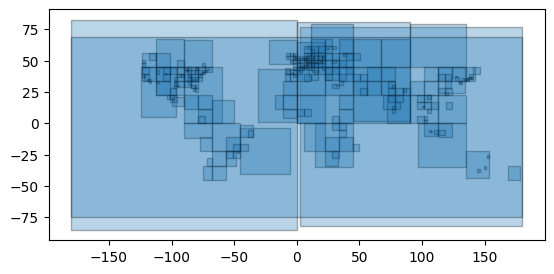

In [23]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [12]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('endpoint_url', '')
# S3 bucket
bucket = os.getenv('bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

In [13]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [14]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [15]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
dt_start = df[vs.dt_col].min()
dt_end = df[vs.dt_col].max()

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [16]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

uploading to remote_path fm-geospatial-cos-dev/vectorstore/osm_road/grid=World(4326)/geoparquet/spatial_partition=0q/d4ac3e7ba13645dbb4b23fec093eb8ea.parquet
schema.names ['address', 'admin_level', 'aerialway', 'aeroway', 'amenity', 'barrier', 'boundary', 'building', 'craft', 'emergency', 'geological', 'geometry', 'highway', 'historic', 'is_in', 'land_area', 'landuse', 'leisure', 'man_made', 'military', 'name', 'name:en', 'natural', 'office', 'osm_id', 'osm_node_id', 'osm_relation_id', 'osm_timestamp', 'osm_version', 'osm_way_id', 'other_tags', 'place', 'power', 'public_transport', 'pyogrio_layer', 'railway', 'ref', 'route', 'shop', 'sport', 'tourism', 'type', 'waterway', 'z_order', '_root']
schema.types [DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(binary), DataType(string), DataType(string), DataType(string), DataType(null),

In [17]:
vs.stac_json_folder_submitted

'data/vectorstore/osm_road/grid=World(4326)/stac/submitted'

In [18]:
vs.stac_url

'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com'

In [19]:
vs.collection_id

'vector-osm-road'